# Ядерные методы

## Метод опорных векторов

Мы уже познакомились с несколькими моделями классификации: метод ближайших соседей, линейный и квадратичный дискриминантный анализ и логистическая регрессия. Сегодня мы познакомимся с ещё одним методом, который в своей основе имеет следующее соображение: 

`Между точками двух классов можно построить разные разделяющие поверхности, давайте построим из них лучшую. Лучшей будем считать ту поверхность, которая наиболее удалена от точек обоих классов.`

<img style="width: 60%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/d12R1pS2/different-decision-surfaces.png"/>

Эта идея как бы вносит в модель регуляризацию, чтобы разделяющая поверхность проходила подальше от имеющихся данных, чтобы предотвратить переобучение.


### Постановка задачи 1

Получается, что мы хотим найти две ближайшие точки в каждом из классов и провести срединный перпендикуляр, потому что именно срединный перпендикуляр будет равноудалён от точек обоих классов, а значит будет максимизировать расстояние до обоих классов.

Но важно отметить, что нам нужны не просто две ближайшие точки из каждого класса, а две ближайшие точки, принадлежащие выпуклым оболочкам двух классов.

<img style="width: 40%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/Nj1KMnjz/convex-hull.png"/>

Математически это можно выразить так: 

Пусть мы имеем набор данных $D=\{(\overline{x}_n,t_n)\}_{n=1}^N$ в котором содержатся точки двух классов $C_1=\{\overline{x}_n|t_n=1\}$ и $C_2=\{\overline{x}_n|t_n=-1\}$.

И мы хотим минимизировать $$\min||\overline{a}-\overline{b}||_2^2,$$ гдe $\overline{a}\in \mathrm{Conv}(C_1)$, $\overline{b}\in \mathrm{Conv}(C_2)$. То есть $$\overline{a}=\sum_{n:t_n=1}\alpha_n\overline{x}_n,\;\;\; \overline{b}=\sum_{n:t_n=-1}\alpha_n\overline{x}_n,$$ $$\forall n \text{ выполнено } \alpha_n>0\text{ и }\sum_{n:t_n=1}\alpha_n = \sum_{n:t_n=-1}\alpha_n=1.$$
Далее по точкам $\overline{a}$ и $\overline{b}$ несложно вычислить параметры для прямой (гиперплоскости), которая являлась бы срединным перпендикуляром.

Можно записать следующую задачу оптимизации:

$$\min_{\overline{\alpha}}\left|\left|\sum_{n:t_n=1}\alpha_n\overline{x}_n-\sum_{n:t_n=-1}\alpha_n\overline{x}_n\right|\right|_2^2,$$
$$\forall n: \alpha_n>0\text{ и }\sum_{n:t_n=1}\alpha_n = \sum_{n:t_n=-1}\alpha_n=1.$$

Это задача квадратического программирования. Её можно решать, можно получить искомую прямую, но это тяжело.

### Постановка задачи 2

Мы можем попробовать решить задачу напрямую, не применяя соображения про срединный перпендикуляр.

Пусть мы хотим провести прямую и максимизировать зазор между прямой и получаемыми классами.

Мы хотим построить прямую (гиперплоскость), задаваемую уравнением $\overline{w}^\top\overline{x}+w_0=0$, так, чтобы максимизировать расстояние до точек данных: $d(\overline{x},\overline{w},w_0)=\frac{|\overline{w}^\top\overline{x}+w_0|}{||\overline{w}||}$.

Параметры мы можем найти следующим образом: $$\max_{\overline{w},w_0}\left(\min_{n}d(\overline{x}_n,\overline{w},w_0)\right)=\max_{\overline{w},w_0}\left(\min_{n}\frac{|\overline{w}^\top\overline{x}_n+w_0|}{||\overline{w}||}\right),$$
где при $\forall n: t_n=1$ выполнено $\overline{w}^\top\overline{x}+w_0>0$ и
при $\forall n: t_n=-1$ выполнено $\overline{w}^\top\overline{x}+w_0<0$.

Последние два условия требуют чтобы точки разных классов располагались по разные стороны от прямой.




Можно воспользоваться тем, как мы обозначили разные классы с помощью значений $-1$ и $1$ и сократить формулы до: $\forall n\; t_n(\overline{w}^\top\overline{x}+w_0)>0$. Также можно преобразовать модуль в числителе целевой функции: $$\max_{\overline{w},w_0}\left(\min_{n}\frac{t_n(\overline{w}^\top\overline{x}_n+w_0)}{||\overline{w}||}\right)=\max_{\overline{w},w_0}\frac{1}{||\overline{w}||}\left(\min_{n}t_n(\overline{w}^\top\overline{x}_n+w_0)\right).$$

Стоит отметить, что полученная задача оптимизации имеет очень неприятный вид, поскольку целевая функция задана кусочно, вызвано это наличием и минимума и максимума.

Для того, чтобы упростить рассматриваемую задачу, заметим, что нам не важна норма вектора $\overline{w}$, а лишь его направление. Поэтому мы можем перейти к следующей задаче:

$$||\overline{w}||=const: \min_nt_n(\overline{w}^\top\overline{x}_n+w_0)=1$$

То есть мы говорим, что хотим найти $\overline{w}$ такое, чтобы точки обоих классов находились на некотором расстоянии от прямой. Но постановка задачи всё ещё сложная: нам необходимо выполнение условия, включающего в себя минимум. Поэтому от минимума можно перейти к неравенству. В итоге получим следующую постановку задачи:

$$\min_{\overline{w},w_0}||\overline{w}||^2$$
$$\forall n \;\; t_n(\overline{w}^\top\overline{x}_n+w_0)\geqslant1$$

В такой постановке задачу уже несложно решать. И в этой задаче уже совсем немного переменных: их всего $d+1$, где $d$ $-$ это размерность пространства, где находятся векторы $\overline{x}_n\in\R^d$.

А теперь давайте применим рассмотренную модель на практике.

In [1]:
from sklearn.svm import SVC, SVR
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.inspection import DecisionBoundaryDisplay

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib import colors
cmap = colors.LinearSegmentedColormap(
    'red_blue_classes',
    {'red': [(0, 1, 1), (1, 0.7, 0.7)],
     'green': [(0, 0.7, 0.7), (1, 0.7, 0.7)],
     'blue': [(0, 0.7, 0.7), (1, 1, 1)]})
# Генерация смеси распределений
def gen_smes(mean, cov, n_points, target):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    return X, Y

def get_meshgrid(nx=200, ny=200):
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    return np.meshgrid(np.linspace(x_min, x_max, nx), np.linspace(y_min, y_max, ny))

def plot_colormesh_svm(ax, model):
    xx, yy = get_meshgrid()
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.pcolormesh(xx, yy, Z,cmap=cmap, norm=colors.Normalize(0., 1.), zorder=0)
    ax.contour(xx, yy, Z, [-1, 0, 1], linewidths=2., colors='white', linestyles=['--', '-', '--'])

def plot_colormesh_svm_multiclass(axes, model):
    xx, yy = get_meshgrid()
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape((*xx.shape, len(axes)))
    for i in range(len(axes)):
        axes[i].pcolormesh(xx, yy, Z[...,i],cmap=cmap, norm=colors.Normalize(0., 1.), zorder=0)
        axes[i].contour(xx, yy, Z[...,i], [-1, 0, 1], linewidths=2., colors='white', linestyles=['--', '-', '--'])

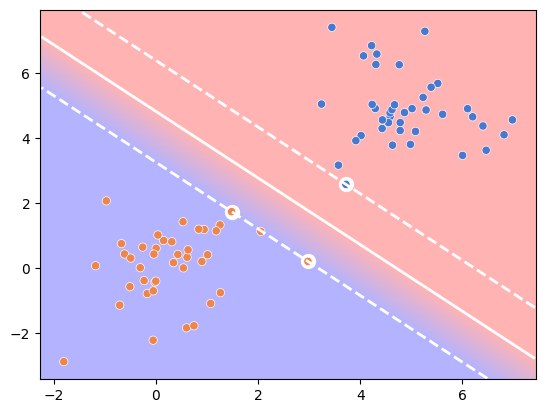

In [2]:
np.random.seed(31)
X,Y = gen_smes(np.array([[5,5], 
                [0,0]]),
               np.array([[[1,0],[0,1]], 
                [[1,0.3,],[0.3,1]]]), np.array([40,40]), np.array([1,2]))

model = SVC(kernel="linear", C=1e10)
model.fit(X,Y)
plt.scatter( model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

plot_colormesh_svm(plt.gca(), model)


Как мы видим, нет никаких проблем с работой этой модели. Мы получили именно то, что хотели $-$ прямую, которая разделяет два класса и находится как можно дальше от их границ.

Белым обведены **опорные векторы**, которые определяют проводимую прямую.

### Случай неразделимых классов

Идейно метод опорных векторов прекрасно работает если классы разделяются прямой, но что делать в случае неразделимых классов?

<img style="width: 40%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/zDCDThrB/reduced-convex-hull.png"/>

Для разрешения этой проблемы мы можем перейти от рассмотрения выпуклой оболочки к рассмотрению сокращённой выпуклой оболочки.

То есть в постановке задачи 1 можно рассматривать не все точки $\sum_{n}\alpha_n\overline{x}_n$ выпуклой оболочки, для которых $\sum_{n}\alpha_n = 1$, а точки, для которых $\sum_{n}\alpha_n = A<1$.

Но, как мы уже отмечали, первая постановка задачи выглядит совсем плохо. Попробуем адаптировать постановку задачи 2.

<img style="width: 40%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/ZRJKtrTV/add-slack.png"/>

Для этого мы разрешим нашей модели ошибаться, а в целевую функцию добавим штраф за ошибку. Получим следующую задачу:

$$\min_{\overline{w},w_0,\overline{Z}} ||\overline{w}||^2_2+C\sum_{n}Z_n,$$
$$\forall n \;\; t_n(\overline{w}^\top\overline{x}_n+w_0)+Z_n\geqslant1, \;\; Z_n\geqslant0.$$

Получается, что $Z_n$ это то, насколько точка может попадать в зазор между классами. Опорными являются все векторы, для которых $Z_n$ не нулевой.

Параметр $C > 0$ отвечает за силу регуляризации. Если $C$ большое, то опорных векторов будет мало (минимум 2 $-$ по одному из каждого класса), а если $C$ маленькое, то опорных векторов будет много (вплоть до всех точек данных в выборке).



Сгенерируем смесь и проверим как работает наша модель.

<Axes: >

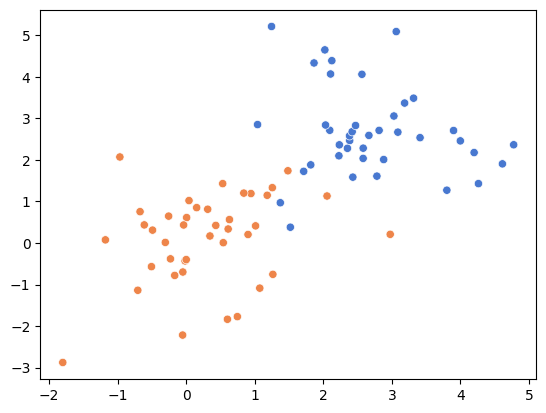

In [3]:
np.random.seed(31)
X,Y = gen_smes(np.array([[2.8,2.8], 
                [0,0]]),
               np.array([[[1,0],[0,1]], 
                [[1,0.3,],[0.3,1]]]), np.array([40,40]), np.array([1,2]))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

При больших значениях параметра $C$ опорными векторами являются точки на границе классов:

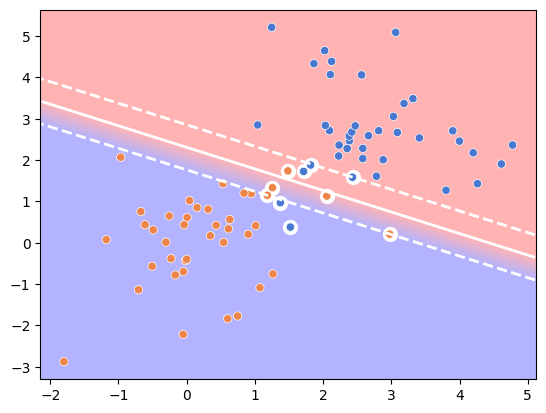

In [4]:
model = SVC(kernel="linear", C=1e4)
model.fit(X,Y)
plt.scatter( model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

plot_colormesh_svm(plt.gca(), model)

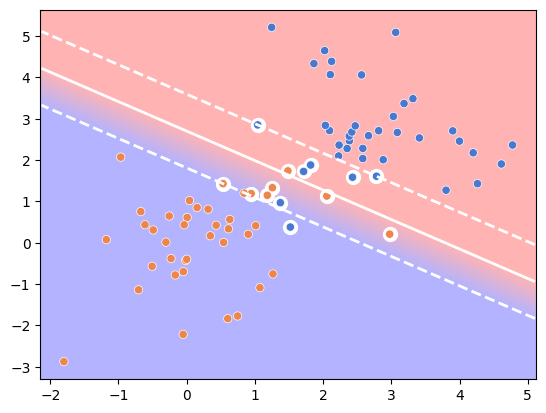

In [5]:
model = SVC(kernel="linear", C=0.5)
model.fit(X,Y)
plt.scatter( model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

plot_colormesh_svm(plt.gca(), model)

И при совсем малых значениях почти все векторы становятся опорными:

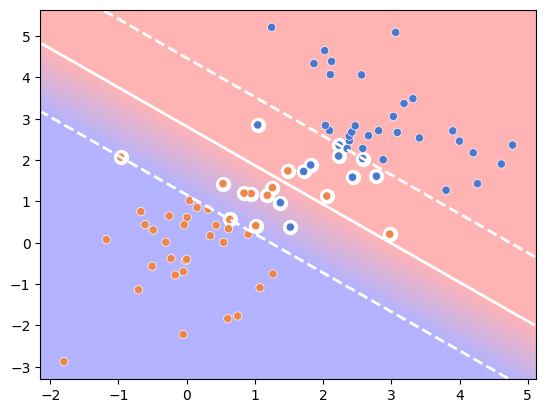

In [6]:
model = SVC(kernel="linear", C=1e-1)
model.fit(X,Y)
plt.scatter( model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

plot_colormesh_svm(plt.gca(), model)

### Постановка задачи 3

Мы познакомились с двумя взглядами на поставленную задачу, далее мы познакомимся с "лучшей" постановкой задачи. Для её получения, давайте "решим" задачу в предыдущей постановке относительно $\overline{w}$ и $w_0$, для этого запишем Лагранжиан. Вектор $\alpha$ $-$ вектор множителей Лагранжа. 

$$L(\overline{w},w_o,\overline{\alpha})=\frac{1}{2}||\overline{w}||^2-\sum_{n}\alpha_n(t_n(\overline{w}^\top\overline{x}_n+w_o)-1),\;\; \forall n, \alpha_n\geqslant0$$

Теперь перейдём к двойственной задаче и будем максимизировать Лагранжиан по $\overline{\alpha}$. Для этого найдём экстремум, приравняв частные производные к кулю:

$$\nabla_{\overline{w}}L=\overline{w}-\sum_n\alpha_nt_n\overline{x}_n=0,$$

$$\frac{\partial L}{\partial w_0}=-\sum_n\alpha_nt_n=0.$$

Далее мы можем сконструировать новую постановку задачи. Для этого подставим "полученное" значение $\overline{w}=\sum_n\alpha_nt_n\overline{x}_n$:

$$L(\overline{\alpha})=\frac{1}{2}\left(\sum_n\alpha_nt_n\overline{x}_n\right)^\top\left(\sum_n\alpha_nt_n\overline{x}_n\right) - \sum_n\alpha_n\left(t_n\left(\left(\sum_n\alpha_nt_n\overline{x}_n\right)^\top\overline{x}_n+w_0\right)-1\right)=$$
$$=\frac{1}{2}\sum_n\sum_m \alpha_n\alpha_m t_n t_m \overline{x}_n^\top\overline{x}_m - \sum_n\sum_m \alpha_n\alpha_m t_n t_m \overline{x}_n^\top\overline{x}_m + \sum_n \alpha_n + w_0\sum_n \alpha_n t_n$$

В итоге получим целевую функцию:

$$L(\overline{\alpha}) = \sum_n \alpha_n - \frac{1}{2}\sum_n\sum_m \alpha_n\alpha_m t_n t_m \overline{x}_n^\top\overline{x}_m \rightarrow \max_{\overline{\alpha}}$$

при $\forall n \;\; \alpha_n \geqslant 0$ и $\sum_n\alpha_nt_n=0$.

Такая постановка задачи $-$ лучшая. Лучшая потому что в ней нет явного упоминания весов $\overline{w}$, можно сказать, что эти веса нам вообще не нужны. А зависимость от точек данных $\overline{x}$ выражается в виде скалярного произведения $\overline{x}_n^\top\overline{x}_m=(\overline{x}_n,\overline{x}_m)$.

Для получения предсказаний модели нам потребуется вычислить $y(\overline{x})=\overline{w}^\top\overline{x}+w_0=\sum_n\alpha_n t_n (\overline{x}_n,\overline{x}) + w_0$. И получается, что для вычисления предсказаний тоже не нужно знать сами веса.

Про полученную задачу оптимизации есть полезное замечание, называемое Условием Каруша-Куна-Таккера:
$$\forall n \;\; \alpha_n\geqslant 0,$$
$$t_n y(\overline{x}_n)-1\geqslant 0,$$
$$\alpha_n(t_n y(\overline{x}_n)-1)=0.$$

Последнее условие как раз самое интересное. Оно гласит, что для любого $n$ либо $\alpha_n$ равно $0$, либо $t_n y(\overline{x}_n)-1$ равно $0$.

Точки, для которых $t_n y(\overline{x}_n)-1$ равно $0$ $-$ лежат на минимальном расстоянии от разделяющие прямой и являются **опорными векторами**. Именно **опорные векторы** дают ненулевой вклад в вектор весов $\overline{w}$. Получается, что результат обучения модели это вектор $\overline{\alpha}$ и точки данных $(\overline{x}_n,t_n)$, для которых $\alpha_n$ не равно $0$.

## Ядерные методы

Давайте обратимся к задаче классификации в случае если классы не линейно разделимы.

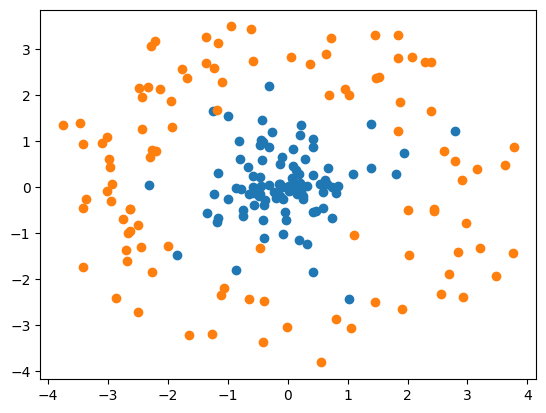

In [7]:
radiuses = [0, 3]
sigmas = [1, 0.5]
classes = [1, 2]
N = 100
X = []
Y = []
for r, sigma, c in zip(radiuses, sigmas, classes):
    angles = np.random.uniform(0, 2 * np.pi, N)
    radius = np.random.normal(r, sigma, N)
    X1 = radius * np.cos(angles)
    X2 = radius * np.sin(angles)
    plt.scatter(X1, X2)
    X.append(np.hstack([X1[:,None], X2[:,None]]))
    Y.append(np.ones(N) * c)
X = np.concatenate(X, axis=0)
Y = np.concatenate(Y, axis=0)

Мы уже умеем применять полиномиальные признаки и нет никаких проблем с тем, чтобы скомбинировать их с методом Опорных векторов:

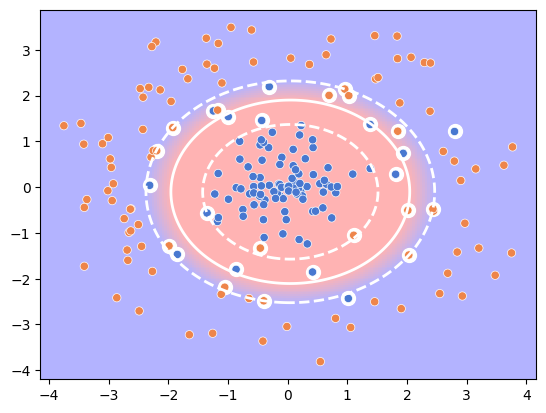

In [8]:
model = SVC(kernel="linear")
pipe = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        model
    )
pipe.fit(X,Y)

plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)
plot_colormesh_svm(plt.gca(), pipe)

Но мы отмечали важный недостаток такого подхода: количество признаков очень сильно растёт. Преимущество метода опорных векторов в том, что такие вычисления можно упростить.

Вспомним как мы это делали ранее. Мы переводили $\overline{x}\in \R^d$ в новое пространство $\overline{\varphi}(\overline{x})\in \R^{d'}$, а далее уже в новом пространстве высокой размерности мы обучали модели. Но заметим особенность третьей постановки задачи: в ней $\overline{x}$ упоминается не в одиночестве, а в виде скалярного произведения с другим вектором: $\overline{x}_n^\top\overline{x}_m$.

Поэтому после перехода в новое пространство $\R^{d'}$ будет встречаться уже скалярное произведение преобразованных векторов: $\overline{\varphi}(\overline{x}_n)^\top \overline{\varphi}(\overline{x}_m)$.

Давайте представим, что мы хотим для вектора $x=(x_1,x_2)^\top$ получить полиномиальные признаки второй степени $\overline{\varphi}(\overline{x})=(x_1,x_2,x_1x_2,x_1^2,x_2^2)^\top$. Давайте распишем скалярное произведение:

$$\begin{pmatrix}\sqrt{2}\cdot x_1\\\sqrt{2}\cdot x_2\\\sqrt{2}\cdot x_1x_2\\x_1^2\\x_2^2\end{pmatrix}^\top\begin{pmatrix}\sqrt{2}\cdot y_1\\\sqrt{2}\cdot y_2\\\sqrt{2}\cdot y_1y_2\\y_1^2\\y_2^2\end{pmatrix}=
2x_1y_1+2x_2y_2+2x_1y_1x_2y_2+x_1^2y_1^2+x_2^2y_2^2=$$

$$= 2\overline{x}^\top\overline{y} + (x_1y_1+x_2y_2)^2 = 2\overline{x}^\top\overline{y} + (\overline{x}^\top\overline{y})^2 = (\overline{x}^\top\overline{y} + 1)^2 - 1.$$

Получилось, что мы можем заменить скалярное произведение $\overline{\varphi}(\overline{x})^\top\overline{\varphi}(\overline{y})$ на некоторую функцию $k(\overline{x},\overline{y})$, называемую **ядром**, а вычисления функции $\overline{\varphi}$ мы можем избежать, тем самым мы упростим проводимые вычисления.

В общем виде ядро $k(\overline{x},\overline{y})= (\overline{x}^\top\overline{y} + 1)^l - 1$ даёт нам полиномиальные признаки степени $l$. Заметьте, что сложную операцию извлечения полиномиальных признаков, требующую много раз возвести числа в степень,  мы заменили на всего одно возведение числа в степень.

Тут важно отметить, что метод опорных векторов за счёт использования ядер позволяет избежать сложных вычислений, связанных с переходом в новое пространство. Но за плюсы приходится платить минусами: модель более трудоёмкая и в обучении и в использовании. Для получения предсказания придётся перебрать все опорные векторы и вычислить ядра.

В библиотеке scikit-learn в методе опорных векторов уже реализованы разные ядра, за это отвечает параметр *kernel*. Ядро `poly` строит полиномиальные признаки описанным выше способом.

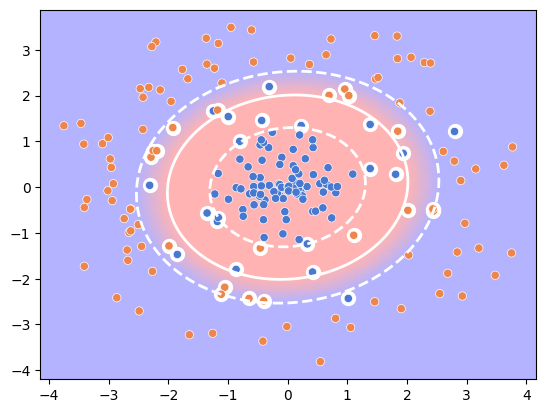

In [9]:
model = SVC(kernel="poly", degree=2)
model.fit(X,Y)

plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)
plot_colormesh_svm(plt.gca(), model)

Может показаться, что разницы в работе нет, но разница проявляется в быстродействии алгоритма. А если вектор $\overline{x}$ изначально находится в пространстве высокой размерности, то может оказаться что полиномиальные признаки неприменимы напрямую, а **kernel trick** в методе опорных векторов сработает.

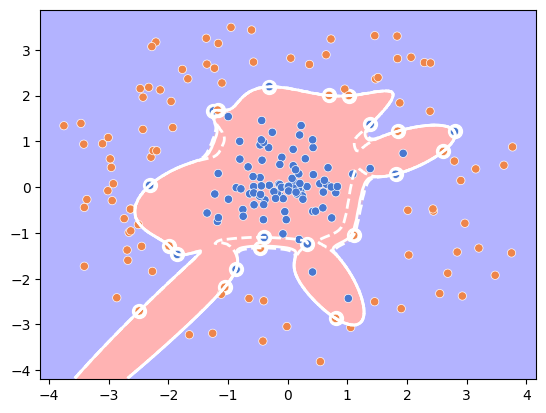

In [10]:
model = SVC(kernel="linear")
pipe = make_pipeline(
        PolynomialFeatures(degree=28, include_bias=False),
        model
    )
pipe.fit(X,Y)

plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)
plot_colormesh_svm(plt.gca(), pipe)

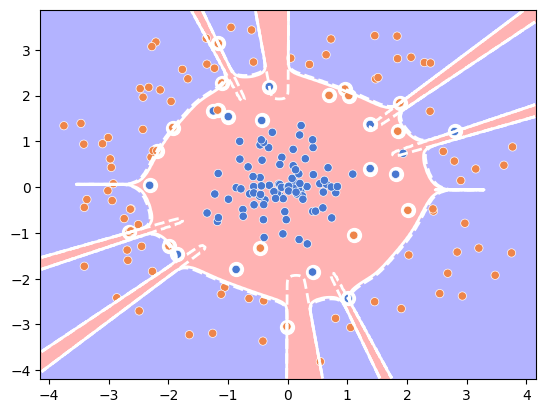

In [11]:
model = SVC(kernel="poly", degree=50)
model.fit(X,Y)

plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)
plot_colormesh_svm(plt.gca(), model)

Конца работы полиномиальных признаков степени выше $28$ дождаться мне не удалось, а SVC спокойно работает даже с $50$ степенью признаков.

А что даже более важно $-$ само преобразование $\overline{\varphi}$ нам не интересно. Если мы сможем определить **ядро**, то этого вполне достаточно для работы метода.

К примеру есть ядро RBF $-$ радиальных базисных функций, задаваемое функцией:

$$k(\overline{x},\overline{y})=e^{-\frac{||\overline{x}-\overline{y}||^2}{2\sigma^2}}.$$

Признаки мы получаем из попарных расстояний точек данных друг от друга. И самое интересное в этом ядре - то, что преобразование $\overline{\varphi}$ отображает точку в бесконечномерное пространство. Давайте взглянем почему это так. Сначала распишем что такое длина вектора $\overline{x}-\overline{y}$:

$$||\overline{x}-\overline{y}||^2=(\overline{x}-\overline{y}, \overline{x}-\overline{y})=(\overline{x},\overline{x}) - 2(\overline{x},\overline{y})+(\overline{y},\overline{y}).$$

$$k(\overline{x},\overline{y})=e^{-\frac{\overline{x}^\top\overline{x}}{2\sigma^2}}e^{-\frac{\overline{y}^\top\overline{y}}{2\sigma^2}}e^{\frac{\overline{x}^\top\overline{y}}{\sigma^2}}$$

Экспоненту можно расписать в виде суммы рядя:

$$e^{\frac{\overline{x}^\top \overline{y}}{\sigma^2}}
=
\sum_{n=0}^{\infty}
\frac{1}{n!}
\left(\frac{\overline{x}^\top \overline{y}}{\sigma^2}\right)^n,$$
 
что уже можно разделить относительно $\overline{x}$ и $\overline{y}$. Получится, что $\overline{\varphi}(\overline{x})$ состоит из бесконечного числа мономов.


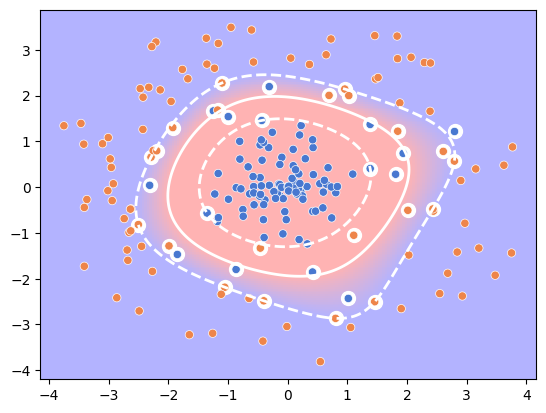

In [12]:
model = SVC(kernel="rbf", C=1e1, gamma=1e-1)
model.fit(X,Y)

plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)
plot_colormesh_svm(plt.gca(), model)

## Классификация нескольких классов с SVM

Метод опорных векторов плохо обобщается на разделение нескольких классов. Точнее, никак не обобщается.

Для работы метода опорных векторов многоклассовая классификация сводится к случаю двух классов. Есть два способа:

- one vs. one. Строятся классификаторы для отделения классов попарно, а затем между ними устраивается голосование.  Получается всего $C_n^2=\frac{M(M-1)}{2}$ классификаторов. Случаи неопределённости, возникающие когда количество голосов совпадает, решаются с помощью оценки степени принадлежности, предоставляемой каждым из классификаторов. 

    В случае метода опорных векторов в качестве такой функции используется зазор между точкой и разделяющей поверхностью. 

- one vs. rest. В данном случае строятся классификаторы для отделения каждого класса от всех остальных классов вместе взятых. Всего получается всего $M$ классификаторов. Также возникает необходимость разрешения случаев неопределённости. 

    Но для данного метода есть и более важная проблема: при такой стратегии разделяющая поверхность может иметь очень сложный вид даже если попарно классы отличить довольно просто.


На изображении ниже продемонстрирована разница между двумя этими методами.

<img style="width: 80%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/FzW7vz3G/ovo-ovr.png"/>

Мы получили совершенно разные классификаторы. Также обратите внимание, что "фиолетовый" класс невозможно отделить прямой от других классов.

Важно отметить, что в sci-kit learn в реализации метода опорных векторов не строятся настоящие классификаторы для стратегии **ovr**. Внутри всё также строятся **ovo** классификаторы, но их оценки принадлежности каждому классу суммируются для получения оценок в формате **ovr**.

In [13]:
X,Y = gen_smes(mean=np.array([[-3,-3],
                [0,5],
                [5,0],
                [8,8]]),
               cov=np.array([np.eye(2,2), np.eye(2,2), np.eye(2,2),np.eye(2,2)]),
               n_points=np.array([40,40,40,40]), 
               target=np.array([1,2,3,4]))

Мы можем увидеть классификаторы, разделяющие классы попарно.

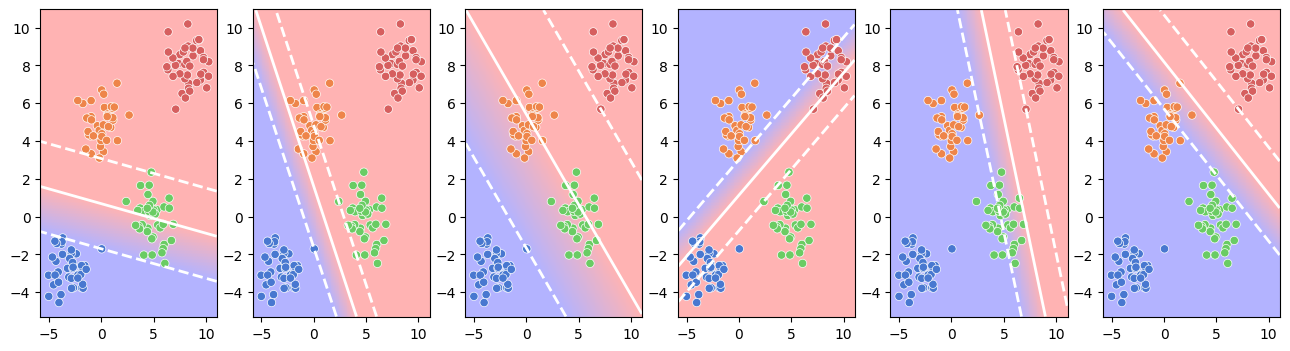

In [14]:
method = "ovo"
model = SVC(kernel="linear", C=1, decision_function_shape=method)
model.fit(X,Y)
n_classes = 4

if method == "ovo":
    fig,axes = plt.subplots(1, n_classes * (n_classes-1)//2)
else:
    fig,axes = plt.subplots(1, n_classes)

fig.set_size_inches(16,4)

for ax in axes:
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False,ax=ax)
    
    
plot_colormesh_svm_multiclass(axes, model)

А тут мы можем увидеть результат агрегации этих классификаторов:

<Axes: >

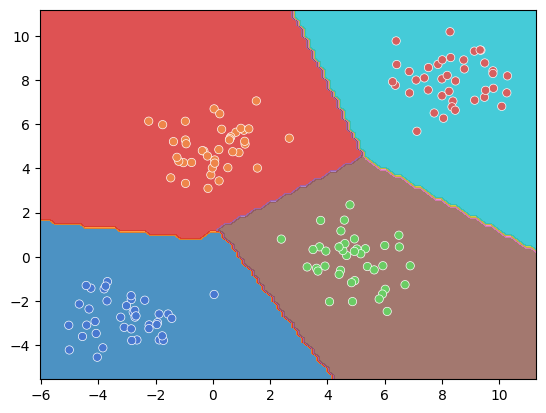

In [15]:
DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        cmap=plt.cm.tab10,
        alpha=0.8,
    )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

А при применении метода `ovr` мы увидим следующее. Разделяющие поверхности выглядят странно именно потому, что это не обученные `ovr`-классификаторы, а агрегированные `ovo`-классификаторы так, чтобы получить не корректный классификатор, а функцию для оценки принадлежности. Поэтому мы и видим очень странные поверхности.

<Axes: >

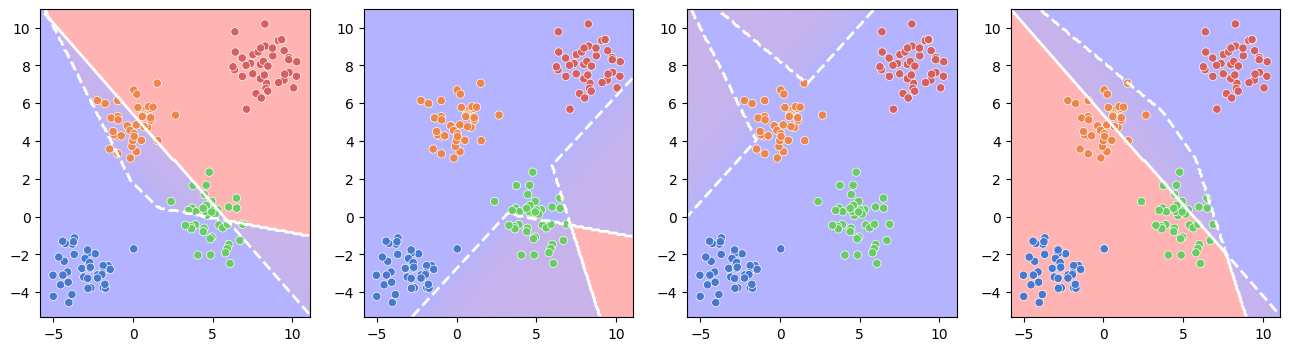

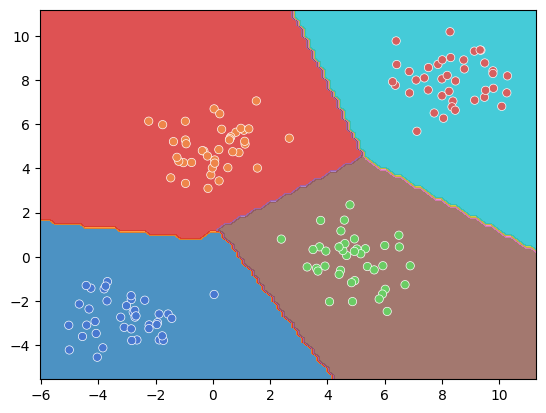

In [16]:
method = "ovr"
model = SVC(kernel="linear", C=1, decision_function_shape=method)
model.fit(X,Y)
n_classes = 4

if method == "ovo":
    fig,axes = plt.subplots(1, n_classes * (n_classes-1)//2)
else:
    fig,axes = plt.subplots(1, n_classes)

fig.set_size_inches(16,4)

for ax in axes:
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False,ax=ax)
    
    
plot_colormesh_svm_multiclass(axes, model)

DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        cmap=plt.cm.tab10,
        alpha=0.8,
    )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

## Тонкости использования ядер

А теперь давайте снова попробуем применить метод опорных векторов с разными ядрами.

In [17]:
radiuses = [0, 3, 4.5]
sigmas = [1, 0.5, 0.2]
classes = [1, 2, 3]
N = 100
X = []
Y = []
for r, sigma, c in zip(radiuses, sigmas, classes):
    angles = np.random.uniform(0, 2 * np.pi, N)
    radius = np.random.normal(r, sigma, N)
    X1 = radius * np.cos(angles)
    X2 = radius * np.sin(angles)
    X.append(np.hstack([X1[:,None], X2[:,None]]))
    Y.append(np.ones(N) * c)
X = np.concatenate(X, axis=0)
Y = np.concatenate(Y, axis=0)

<Axes: >

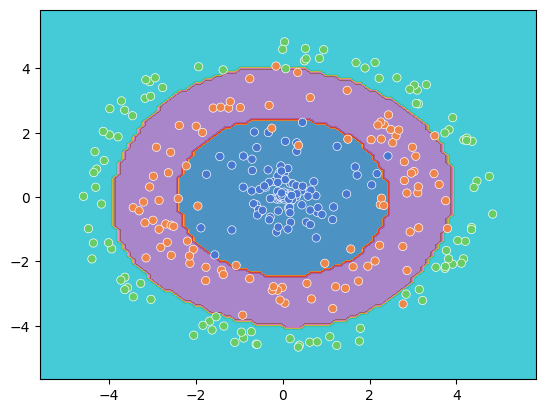

In [18]:
model = SVC(kernel="poly", degree=4, C=0.5, gamma=1e-1, decision_function_shape="ovo")
model.fit(X,Y)

DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        cmap=plt.cm.tab10,
        alpha=0.8,
    )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

Модель вполне успешно справляется с поставленной задачей.

А давайте немного сместим центры колец из точки $(0,0)$.

In [19]:
radiuses = [0, 3, 4.5]
sigmas = [1, 0.5, 0.2]
classes = [1, 2, 3]
N = 100
X = []
Y = []
for r, sigma, c in zip(radiuses, sigmas, classes):
    angles = np.random.uniform(0, 2 * np.pi, N)
    radius = np.random.normal(r, sigma, N)
    X1 = radius * np.cos(angles)
    X2 = radius * np.sin(angles)
    X.append(np.hstack([X1[:,None], X2[:,None]]))
    Y.append(np.ones(N) * c)
X = np.concatenate(X, axis=0)
X[:,0] +=1
Y = np.concatenate(Y, axis=0)

Тогда SVM перестанет работать!

<Axes: >

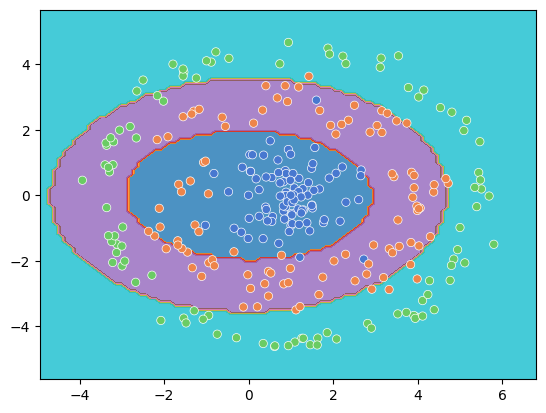

In [20]:
model = SVC(kernel="poly", degree=2, C=0.5, gamma=1e-1, decision_function_shape="ovo")
model.fit(X,Y)

DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        cmap=plt.cm.tab10,
        alpha=0.8,
    )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)


Это происходит из-за вида применяемого ядра.

Полиномиальное ядро имеет вид $$k(\overline{x},\overline{y})=(\gamma\overline{x}^\top\overline{y}+c_0)^{d}.$$

Коэффициенты $\gamma$ (*gamma* в sklearn), *c_0* (*coef0* в sklearn) сильно влияют на результат. По умолчанию значение coef0 установлено 0. Это значит, что в признаках нет смешанных мономов (к примеру $x_0x_1$), поэтому получаемые эллипсы могут иметь центом лишь точку $(0,0)$.

<Axes: >

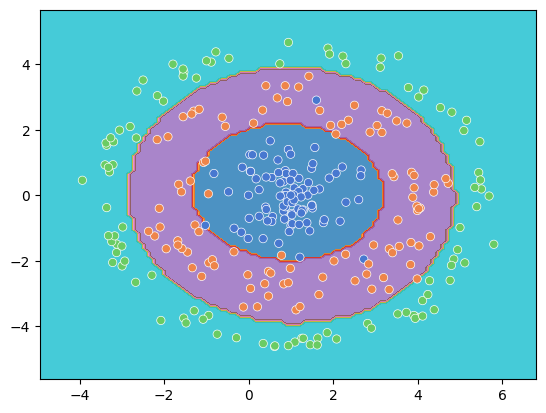

In [21]:
model = SVC(kernel="poly", degree=2, C=0.5, gamma=1e-1, decision_function_shape="ovo",
        coef0=1) # установили значение 1
model.fit(X,Y)

DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        cmap=plt.cm.tab10,
        alpha=0.8,
    )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

Параметр *gamma* тоже выбран не случайно. Если его уменьшить, всё сломается.

<Axes: >

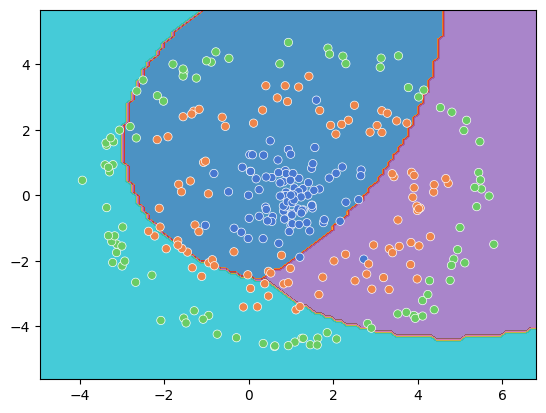

In [22]:
model = SVC(kernel="poly", degree=2, C=0.5, gamma=1e-2, decision_function_shape="ovo", coef0=1)
model.fit(X,Y)

DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        cmap=plt.cm.tab10,
        alpha=0.8,
    )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

Получается, что для применения SVM с полиномиальным ядром требуется выбрать оптимально довольно много параметров. Небольшое изменение одного из параметров может сильно испортить модель.

На самом деле, в SVM полиномиальные признаки будут всегда проигрывать радиальным базисным функциям. Как мы выше показали, *rbf* эквивалентно базису из бесконечного числа мономов. Поэтому радиальные базисные функции почти всегда будут работать лучше (хотя бы потому, что гиперпараметров всего два).

<Axes: >

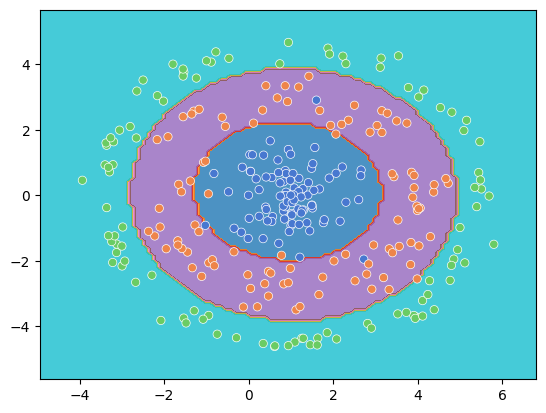

In [23]:
model = SVC(kernel="rbf", C=1e1, gamma=1e-2)
model.fit(X,Y)

DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        cmap=plt.cm.tab10,
        alpha=0.8,
    )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)

## Проблема несбалансированности классов

Метод опорных векторов сильно зависит от количества данных в классах и на нём сильно сказывается дисбаланс классов.

Природа возникающей проблемы проста: в одном классе 40 точек это все точки этого класса, а для другого 40 точек это лишь малая часть точек на границе. Из-за этого разделяющая поверхность сильно смещается.

In [24]:
X,Y = gen_smes(mean=np.array([[0,0],
                [0,5],]),
               cov=np.array([np.eye(2,2)*3, np.eye(2,2)]),
               n_points=np.array([4000,40]), 
               target=np.array([1,2]))

Около половины точек оранжевого класса классифицируются неверно:

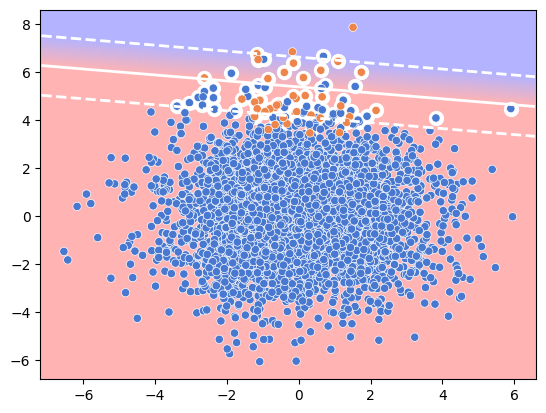

In [25]:
model = SVC(kernel="linear", C=1e1, gamma=1e-1)
model.fit(X,Y)

plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)
plot_colormesh_svm(plt.gca(), model)

В класс можно указать параметр `class_weight` для изменения вклада классов в целевую функцию.

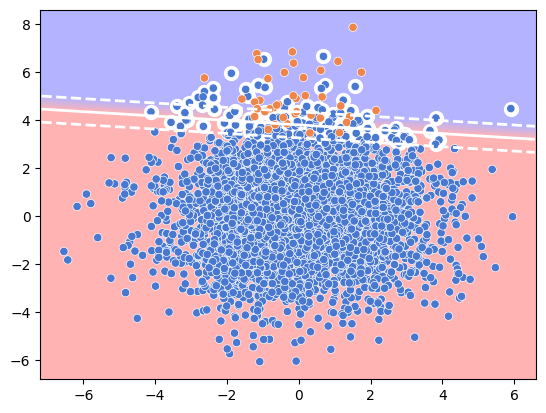

In [26]:
model = SVC(kernel="linear", C=1e1, gamma=1e-1, class_weight={1:1, 2:10})
model.fit(X,Y)

plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], color='white', s=100 )
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False)
plot_colormesh_svm(plt.gca(), model)

# Метод опорных векторов в регрессии

У нас есть данные $\{(\overline{x}_n,y_n)\}_n=1^N$, $\overline{x}_n\in\R^d$. Мы хотим обучить модель:

$$f(x)=\overline{w}^\top\overline{x}_n+w_0.$$

Функция ошибки выглядит следующим образом:

$$L_\varepsilon(\overline{w},w_0)=\sum_n\max\{0,|y_n-f(x_n)|-\varepsilon\}.$$

Мы стремимся построить такую прямую, чтобы все точки попали в $\varepsilon$-трубу этой прямой. Предсказания, попавшие в $\varepsilon$-трубу, не штрафуются.

Можно сформулировать следующую постановку задачи:

$$\min_{\overline{w},w_0,\overline{Z},\overline{Z}'}\frac{1}{2}||\overline{w}||_2^2+C\sum_n(Z_n+Z_n'),$$

$$\begin{cases}
y_n-\overline{w}^\top\overline{x}_n-w_0\leqslant\varepsilon+Z_n,\\
-y_n+\overline{w}^\top\overline{x}_n+w_0\leqslant\varepsilon+Z_n',\\
Z_n\geqslant0,\\
Z_n'\geqslant0.
\end{cases}$$

Значения $\overline{Z}$ и $\overline{Z}'$ позволяет точкам выходить из $\varepsilon$-трубы.

Для получения двойственной задачи воспользуемся тем же трюком. 

$$\min_{\overline{w},w_0,\overline{Z},\overline{Z}'}\frac{1}{2}\overline{w}^\top\overline{w}+C\sum_n(Z_n+Z_n') + \sum_n\alpha_n(y_n-\overline{w}^\top\overline{x}_n-w_0-\varepsilon-Z_n) + $$

$$ + \sum_n\alpha_n'(-y_n+\overline{w}^\top\overline{x}_n+w_0-\varepsilon-Z_n')-\sum_n\eta_nZ_n-\sum_n\eta_n'Z_n'.$$


Аналогично тому, как мы делали ранее, посчитаем частные производные:

$$\nabla_{\overline{w}}L=\overline{w}-\sum_n\alpha_n\overline{x}_n+\sum_n\alpha_n'\overline{x}_n \; \Rightarrow\; w=\sum_n(\alpha_n-\alpha_n')\overline{x}_n,$$

$$\frac{\partial}{\partial w_0}L=-\sum_n\alpha_n+\sum_n\alpha_n' \; \Rightarrow \; \sum_n(\alpha_n-\alpha_n')=0.$$

Получим двойственную задачу:

$$\max_{\overline{\alpha},\overline{\alpha}'}-\frac{1}{2}\sum_n\sum_m(\alpha_n-\alpha_n')(\alpha_m-\alpha_m')k(\overline{x}_n,\overline{x}_m) + \sum_ny_n(\alpha_n-\alpha_n')-\varepsilon\sum_n(\alpha_n+\alpha_n').$$

Мы снова получили задачу с ядром $k(\cdot,\cdot)$. Применять можно всё те же ядра, которые мы применяли в классификации.

In [27]:
def generate_samples(function, n_samples, x_min=0, x_max=10, sigma=1):
    x = np.random.uniform(x_min, x_max, n_samples)
    y = function(x) + np.random.normal(0, sigma, n_samples)
    return x, y

In [28]:
rel = lambda x: x + np.sin(x*5) + x*x
x_min, x_max = -1,1
x,y = generate_samples(rel, 20, x_min, x_max,0.3)

Мы можем обучить модель используя обычные линейные признаки:

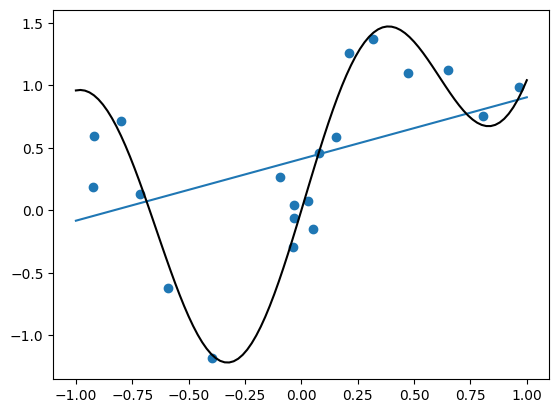

In [29]:
model = SVR(kernel="linear")
model.fit(x[:,None],y)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, y)
plt.plot(t, rel(t),c="black",zorder=100)

plt.plot(t, model.predict(t[:,None]))


А можем взять полиномиальные признаки. Но вот проблема: если просто взять метод из коробки и применить его, то работать ничего не будет. Проблема всё в той же необходимости настройки гиперпараметров.

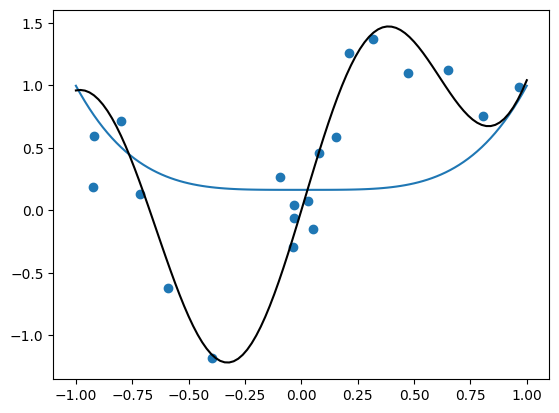

In [30]:
model = SVR(kernel="poly", C=1e2, degree=4)
model.fit(x[:,None],y)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, y)
plt.plot(t, rel(t),c="black", zorder=100)

plt.plot(t, model.predict(t[:,None]))


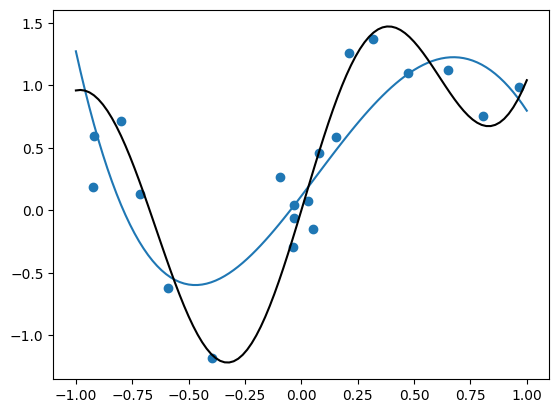

In [31]:
model = SVR(kernel="poly", C=1e3, gamma=1, coef0=1, degree=4)
model.fit(x[:,None],y)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, y)
plt.plot(t, rel(t),c="black", zorder=100)

plt.plot(t, model.predict(t[:,None]))


А можно взять локальные признаки и всё будет работать неплохо даже без подбора параметров:

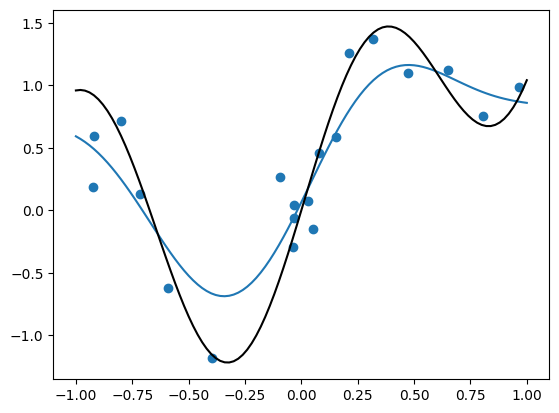

In [32]:
model = SVR(kernel="rbf")
model.fit(x[:,None],y)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, y)
plt.plot(t, rel(t),c="black", zorder=100)

plt.plot(t, model.predict(t[:,None]))


# Домашнее задание

- Загрузите набор данных Ирисов Фишера и устройте обучение гиперпараметров с помощью кросс-валидации в методе опорных векторов для разных ядер (linear, poly, rbf). 
- Напишите класс-обёртку для SVC для построения настоящих `ovr`-классификаторов. Устройте между полученными классификаторами голосование для получения предсказаний. Нарисуйте разделяющие поверхности для полученных классификаторов.